# 거시를 **기준월이 아니라 알게 된 날**로 담다 — ECOS 9종

> `notebooks/01-데이터수집/04.거시를시점으로담다.ipynb` · 2026-09-02 · 이동원

---

## 이 노트북이 답하는 것

> **"7월 물가를 7월 1일에 알 수 있었나?"**

없습니다. 실제 발표는 **8월 4일**이었습니다. 그런데 한국은행 ECOS 는 7월 물가를
`2026-07-01` 이라는 날짜에 얹어서 줍니다. 그대로 붙이면 **34일치 미래**가 학습에
들어갑니다. 경기지수는 7월분이 8월 31일에 나오므로 **61일**입니다.

그리고 이 오류는 **예외를 내지 않고 성능만 올립니다.** 이 프로젝트에서 가장 찾기
어려운 종류의 실수입니다.

이 노트북은 그 문제를 확인하고, 어떻게 막았는지를 그림으로 보여 줍니다.

| 보여 주는 것 | 왜 |
|---|---|
| ECOS 응답에 발표일이 없다는 실측 | 문제의 출발점 |
| 지표별 실제 공표일정 | 규칙의 근거 |
| `known_at` 이 막은 미래의 크기 | 얼마나 심각했나 |
| `as_of` 조회 시연 | 실제로 막히는가 |

---

## 한 줄 요약

**값(`value`)과 그 값을 알게 된 날(`known_at`)을 따로 담고, 쓸 때는 `known_at` 으로
거른다.** 재무에서 접수일(`rcept_dt`)이 하는 일을 거시에서는 계산해서 만듭니다.

## 0. 준비

⚠️ **읽기 전용(`mode=ro`)으로 엽니다.** 수집 배치가 도는 중에 쓰기로 열면 잠금을
다툽니다.

In [1]:
import sqlite3
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import font_manager

sys.path.insert(0, str(Path.cwd().parents[1]))

from common.paths import krx_db_path
from ingest.clients import ecos_data
from ingest.store import macro_store

# 한글 폰트 — 설치된 것 중 먼저 찾아지는 것을 쓴다 (사람마다 OS 가 다르다)
설치됨 = {f.name for f in font_manager.fontManager.ttflist}
for 후보 in ("Malgun Gothic", "NanumGothic", "AppleGothic", "Gulim"):
    if 후보 in 설치됨:
        plt.rcParams["font.family"] = 후보
        break
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

con = sqlite3.connect(f"file:{krx_db_path()}?mode=ro", uri=True)
print(f"DB: {krx_db_path().name}")
print(f"스키마 v{con.execute('PRAGMA user_version').fetchone()[0]}")

DB: krx_cache.db
스키마 v8


## 1. 무엇을 받았나

한국은행 **ECOS**(경제통계시스템)에서 국내 거시지표 9종을 받습니다.
미국을 FRED 가 맡는다면 국내는 ECOS 입니다 — 국내 종목을 분석하면서
"미 국채 10년" 만 보고 "한은 기준금리" 를 안 보면 앞뒤가 맞지 않습니다.

| 묶음 | 지표 | 주기 |
|---|---|---|
| 금리 | 기준금리 · 국고채 3년 · 국고채 10년 | 월 · 일 · 일 |
| 환율 | 원/달러 · 원/엔(100엔) | 일 |
| 물가 | 소비자물가 · 생산자물가 | 월 |
| 경기 | 선행지수 순환변동치 · 동행지수 순환변동치 | 월 |

In [2]:
현황 = pd.DataFrame(macro_store.status(conn=con))
현황["기간"] = 현황["period_min"] + " ~ " + 현황["period_max"]
현황["알게된 날"] = 현황["known_at_min"] + " ~ " + 현황["known_at_max"]
보기 = 현황[["indicator_id", "cycle", "rows", "기간", "알게된 날", "null_values"]]
보기.columns = ["지표", "주기", "행", "기간", "알게된 날", "결측"]
print(f"합계 {현황['rows'].sum():,}행 · 지표 {len(현황)}종")
보기

합계 17,851행 · 지표 9종


,지표,주기,행,기간,알게된 날,결측
0,base_rate,M,205,200908 ~ 202608,20090901 ~ 20260901,0
1,coincident,M,204,200908 ~ 202607,20091005 ~ 20260905,0
2,cpi,M,204,200908 ~ 202607,20090910 ~ 20260810,0
3,jpykrw,D,4208,20090827 ~ 20260902,20090828 ~ 20260903,0
4,ktb10y,D,4207,20090827 ~ 20260901,20090828 ~ 20260902,0
5,ktb3y,D,4207,20090827 ~ 20260901,20090828 ~ 20260902,0
6,leading,M,204,200908 ~ 202607,20091005 ~ 20260905,0
7,ppi,M,204,200908 ~ 202607,20090930 ~ 20260831,0
8,usdkrw,D,4208,20090827 ~ 20260902,20090828 ~ 20260903,0


**2010년이 아니라 2009년 8월부터 받습니다.** 시세는 2010-01-04 부터인데 거시를
그보다 앞서 받아 두는 이유가 있습니다.

거시는 **계단식**으로 씁니다 — 직전 발표치를 다음 발표 전까지 이어 씁니다.
그래서 2009년 12월 물가가 없으면 **2010년 1월 초에 참조할 값이 사라집니다.**

## 2. 🔴 문제 — ECOS 는 발표일을 주지 않는다

ECOS 의 세 서비스를 전부 두드려 확인했습니다 (2026-09-02 실측).

In [3]:
# StatisticSearch 가 주는 칸 전부
spec = ecos_data.INDICATOR_BY_ID["cpi"]
key, _ = ecos_data.load_ecos_key()
칸 = ["STAT_CODE", "STAT_NAME", "ITEM_CODE1", "ITEM_NAME1", "ITEM_CODE2", "ITEM_NAME2",
      "ITEM_CODE3", "ITEM_NAME3", "ITEM_CODE4", "ITEM_NAME4", "UNIT_NAME", "WGT",
      "TIME", "DATA_VALUE"]

print("StatisticSearch 응답 한 행의 칸 (14개):")
for c in 칸:
    표시 = "  ← 기간" if c == "TIME" else ("  ← 값" if c == "DATA_VALUE" else "")
    print(f"  {c}{표시}")
print()
print("StatisticTableList 의 칸 (6개):")
for c in ["P_STAT_CODE", "STAT_CODE", "STAT_NAME", "CYCLE", "SRCH_YN", "ORG_NAME"]:
    print(f"  {c}")
print()
print("🔴 어디에도 '이 값이 언제 공개됐는지' 가 없습니다.")

StatisticSearch 응답 한 행의 칸 (14개):
  STAT_CODE
  STAT_NAME
  ITEM_CODE1
  ITEM_NAME1
  ITEM_CODE2
  ITEM_NAME2
  ITEM_CODE3
  ITEM_NAME3
  ITEM_CODE4
  ITEM_NAME4
  UNIT_NAME
  WGT
  TIME  ← 기간
  DATA_VALUE  ← 값

StatisticTableList 의 칸 (6개):
  P_STAT_CODE
  STAT_CODE
  STAT_NAME
  CYCLE
  SRCH_YN
  ORG_NAME

🔴 어디에도 '이 값이 언제 공개됐는지' 가 없습니다.


그런데 ECOS 는 월별 값을 **기준월 1일**로 줍니다. 아래를 보면 7월 물가가
`2026-07-01` 로 옵니다 — 마치 7월 1일에 알 수 있었던 것처럼요.

In [4]:
series = ecos_data.fetch_series("cpi", years=1)
끝 = pd.DataFrame({
    "ECOS 가 주는 날짜": series["dates"][-4:],
    "기간(원문)": series["periods"][-4:],
    "값": series["values"][-4:],
})
print("소비자물가지수 — ECOS 응답의 마지막 4개")
끝

소비자물가지수 — ECOS 응답의 마지막 4개


,ECOS 가 주는 날짜,기간(원문),값
0,2026-04-01,202604,119.37
1,2026-05-01,202605,119.92
2,2026-06-01,202606,119.99
3,2026-07-01,202607,119.77


## 3. 실제로는 언제 발표되나 — 공표일정 조사

공식 출처에서 옮겨 적은 **실제 발표일**입니다 (2026-09-02 조사).

| 지표 | 공표 주체 | 공표 시점 | 2026년 7월분 |
|---|---|---|---|
| 소비자물가 | 국가데이터처 | 익월 초 (2~6일) | **8.4 (화)** |
| 생산자물가 | 한국은행 | 익월 하순 (18~24일) | **8.21 (금) 06:00** |
| 경기지수 | 국가데이터처 | 익월 말 (29~31일) | **8.31 (월)** |
| 기준금리 | 금통위 | 결정 당일 즉시 | — |
| 국고채·환율 | 한국은행 | 당일~익영업일 | — |

**결정적인 확인 하나 더.** 오늘(9/2) 8월 소비자물가가 발표됐는데, ECOS 의 최신은
아직 **202607** 입니다. 즉 **보도자료보다 ECOS 반영이 늦습니다.**
그래서 공표일에 그대로 맞추면 안 되고, 여유가 필요합니다.

## 4. 그래서 어떻게 정했나 — 실측 공표규칙 + 안전 여유

업계 표준(point-in-time 데이터 관행)도 같은 처방입니다. 정확한 공표일을 모를 때는
*"즉시 이용 가능"* 을 가정하지 말고 **보수적 시차를 적용하라**는 것입니다.

> *"When exact publication dates aren't available, apply a conservative estimated
> lag rather than assuming immediate availability, **erring on the side of caution**."*

In [5]:
규칙 = []
설명 = {
    "ktb3y": "국고채가 익영업일에 반영된다",
    "ktb10y": "국고채가 익영업일에 반영된다",
    "usdkrw": "국고채가 익영업일에 반영된다",
    "jpykrw": "국고채가 익영업일에 반영된다",
    "base_rate": "월별 시계열이라 월중 시점 불명",
    "cpi": "주말 밀림 + ECOS 반영 지연",
    "ppi": "공표일 변동폭이 일주일이다",
    "leading": "월말 발표라 달을 넘긴다",
    "coincident": "월말 발표라 달을 넘긴다",
}
for 이름, 규칙값 in ecos_data.RELEASE_RULES.items():
    if "days" in 규칙값:
        문구 = f"기준일 +{규칙값['days']}일"
    else:
        날 = "말일" if 규칙값["day"] == "end" else f"{규칙값['day']}일"
        문구 = f"{규칙값['months']}개월 뒤 {날}"
    규칙.append({"지표": 이름, "규칙": 문구, "여유를 두는 이유": 설명[이름]})
pd.DataFrame(규칙)

,지표,규칙,여유를 두는 이유
0,ktb3y,기준일 +1일,국고채가 익영업일에 반영된다
1,ktb10y,기준일 +1일,국고채가 익영업일에 반영된다
2,usdkrw,기준일 +1일,국고채가 익영업일에 반영된다
3,jpykrw,기준일 +1일,국고채가 익영업일에 반영된다
4,base_rate,1개월 뒤 1일,월별 시계열이라 월중 시점 불명
5,cpi,1개월 뒤 10일,주말 밀림 + ECOS 반영 지연
6,ppi,1개월 뒤 말일,공표일 변동폭이 일주일이다
7,leading,2개월 뒤 5일,월말 발표라 달을 넘긴다
8,coincident,2개월 뒤 5일,월말 발표라 달을 넘긴다


### 규칙이 실제 공표일보다 늦은가 — 이게 안전의 전부입니다

우리가 정한 시점이 실제 발표보다 **앞서면** 그만큼 미래가 샙니다.
조사한 실제 공표일 20건과 맞대어 봅니다.

In [6]:
from datetime import datetime

실제 = [
    ("cpi", "202601", "20260203"), ("cpi", "202602", "20260306"),
    ("cpi", "202603", "20260402"), ("cpi", "202604", "20260506"),
    ("cpi", "202605", "20260602"), ("cpi", "202606", "20260702"),
    ("cpi", "202607", "20260804"), ("cpi", "202608", "20260902"),
    ("ppi", "202512", "20260120"), ("ppi", "202601", "20260224"),
    ("ppi", "202602", "20260324"), ("ppi", "202603", "20260422"),
    ("ppi", "202604", "20260521"), ("ppi", "202605", "20260619"),
    ("ppi", "202606", "20260722"), ("ppi", "202607", "20260821"),
    ("ppi", "202608", "20260918"),
    ("leading", "202607", "20260831"), ("coincident", "202607", "20260831"),
]
줄 = []
for 지표, 기준월, 공표일 in 실제:
    우리값 = ecos_data.known_at(지표, 기준월)
    차이 = (datetime.strptime(우리값, "%Y%m%d")
            - datetime.strptime(공표일, "%Y%m%d")).days
    줄.append({"지표": 지표, "기준월": 기준월, "실제 공표": 공표일,
               "우리 known_at": 우리값, "차이(일)": 차이,
               "판정": "안전" if 차이 >= 0 else "미래가 샌다"})
대조 = pd.DataFrame(줄)
print(f"실제보다 앞서는 항목: {(대조['차이(일)'] < 0).sum()}건")
대조

실제보다 앞서는 항목: 0건


,지표,기준월,실제 공표,우리 known_at,차이(일),판정
0,cpi,202601,20260203,20260210,7,안전
1,cpi,202602,20260306,20260310,4,안전
2,cpi,202603,20260402,20260410,8,안전
3,cpi,202604,20260506,20260510,4,안전
4,cpi,202605,20260602,20260610,8,안전
5,cpi,202606,20260702,20260710,8,안전
6,cpi,202607,20260804,20260810,6,안전
7,cpi,202608,20260902,20260910,8,안전
8,ppi,202512,20260120,20260131,11,안전
9,ppi,202601,20260224,20260228,4,안전


C:\Users\kik32\AppData\Local\Temp\ipykernel_53868\1640800994.py:18: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\kik32\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


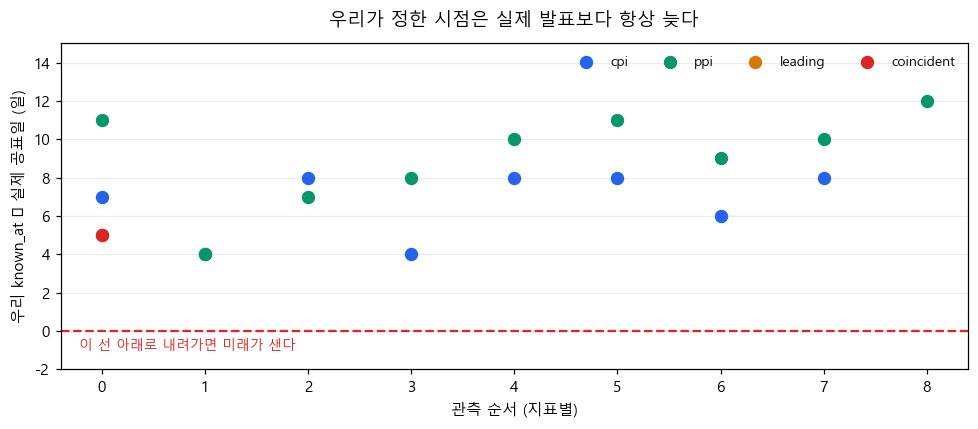

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
색 = {"cpi": "#2563eb", "ppi": "#059669", "leading": "#d97706",
      "coincident": "#dc2626"}
for 지표 in 대조["지표"].unique():
    부분 = 대조[대조["지표"] == 지표]
    ax.scatter(range(len(부분)), 부분["차이(일)"], label=지표,
               color=색.get(지표, "#64748b"), s=60, zorder=3)

ax.axhline(0, color="#dc2626", linewidth=1.5, linestyle="--", zorder=2)
ax.text(0.02, 0.06, "이 선 아래로 내려가면 미래가 샌다",
        transform=ax.transAxes, color="#dc2626", fontsize=9)
ax.set_ylabel("우리 known_at − 실제 공표일 (일)")
ax.set_xlabel("관측 순서 (지표별)")
ax.set_title("우리가 정한 시점은 실제 발표보다 항상 늦다", fontsize=12, pad=12)
ax.legend(frameon=False, ncol=4, fontsize=9)
ax.grid(axis="y", alpha=0.25, zorder=1)
ax.set_ylim(-2, 15)
plt.tight_layout()
plt.show()

## 5. 얼마나 큰 미래를 막았나

ECOS 가 주는 기준월 1일을 그대로 붙였을 때와 견줍니다.

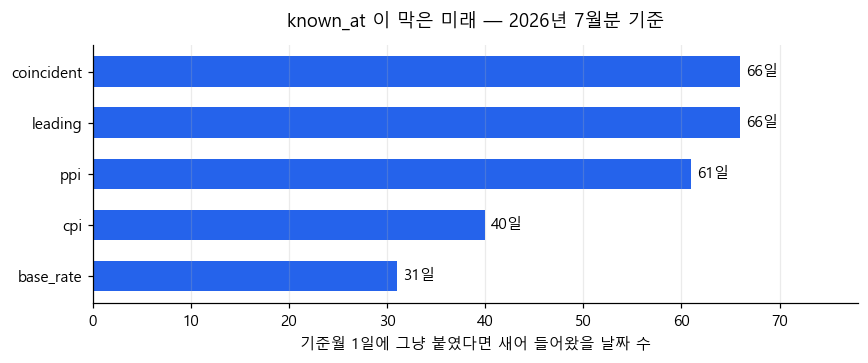

In [8]:
막은일수 = []
for 지표 in ("base_rate", "cpi", "ppi", "leading", "coincident"):
    우리값 = datetime.strptime(ecos_data.known_at(지표, "202607"), "%Y%m%d")
    기준월그대로 = datetime(2026, 7, 1)
    막은일수.append({"지표": 지표, "막은 미래(일)": (우리값 - 기준월그대로).days})
막음 = pd.DataFrame(막은일수).sort_values("막은 미래(일)")

fig, ax = plt.subplots(figsize=(8, 3.4))
막대 = ax.barh(막음["지표"], 막음["막은 미래(일)"], color="#2563eb", height=0.6)
ax.bar_label(막대, fmt="%d일", padding=4, fontsize=10)
ax.set_xlabel("기준월 1일에 그냥 붙였다면 새어 들어왔을 날짜 수")
ax.set_title("known_at 이 막은 미래 — 2026년 7월분 기준", fontsize=12, pad=12)
ax.set_xlim(0, 78)
ax.grid(axis="x", alpha=0.25)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

경기지수가 **66일**로 가장 큽니다. 익월 말에 발표되기 때문입니다.
두 달 가까운 미래를 모델에 먹이고 있었다면, 백테스트 성적은 좋아졌겠지만
실전에서는 그 성적이 나오지 않습니다.

## 6. 실제로 막히는가 — `as_of` 시연

값을 쓸 때는 `period` 가 아니라 **`known_at` 으로 거릅니다.**
`macro_store.as_of(지표, 날짜)` 가 그 일을 합니다.

In [9]:
줄 = []
for 기준일 in ("20260701", "20260710", "20260715", "20260810", "20260901"):
    받음 = macro_store.as_of("cpi", 기준일, conn=con)
    줄.append({
        "이 날 조회하면": 기준일,
        "쓸 수 있는 기간": 받음["period"] if 받음 else "(없음)",
        "값": 받음["value"] if 받음 else None,
        "알게 된 날": 받음["known_at"] if 받음 else "-",
    })
print("소비자물가 — 날짜별로 그때 알 수 있었던 값")
pd.DataFrame(줄)

소비자물가 — 날짜별로 그때 알 수 있었던 값


,이 날 조회하면,쓸 수 있는 기간,값,알게 된 날
0,20260701,202605,119.92,20260610
1,20260710,202606,119.99,20260710
2,20260715,202606,119.99,20260710
3,20260810,202607,119.77,20260810
4,20260901,202607,119.77,20260810


**7월 15일에 조회해도 202607 이 나오지 않습니다.** 202606 이 나옵니다.
ECOS 가 주는 기준월을 그대로 썼다면 이 자리에서 202607(한 달 미래)이 나왔을 것입니다.

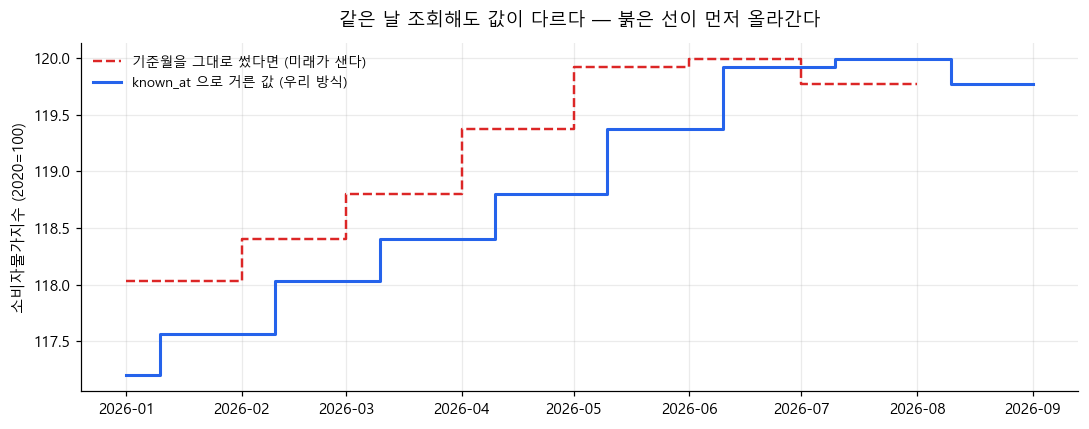

In [10]:
# 계단식으로 이어지는 모습을 그림으로
질의일 = pd.date_range("2026-01-01", "2026-09-01", freq="D")
값들, 기간들 = [], []
for d in 질의일:
    받음 = macro_store.as_of("cpi", d.strftime("%Y%m%d"), conn=con)
    값들.append(받음["value"] if 받음 else None)
    기간들.append(받음["period"] if 받음 else None)

# 비교용 — ECOS 기준월을 그대로 썼다면 (period 로 거른 경우)
원본 = ecos_data.fetch_series("cpi", years=2)
기준월값 = {p: v for p, v in zip(원본["periods"], 원본["values"], strict=True)}
그대로 = [기준월값.get(d.strftime("%Y%m")) for d in 질의일]

fig, ax = plt.subplots(figsize=(10, 4))
ax.step(질의일, 그대로, where="post", color="#dc2626", linewidth=1.6,
        linestyle="--", label="기준월을 그대로 썼다면 (미래가 샌다)")
ax.step(질의일, 값들, where="post", color="#2563eb", linewidth=2,
        label="known_at 으로 거른 값 (우리 방식)")
ax.set_ylabel("소비자물가지수 (2020=100)")
ax.set_title("같은 날 조회해도 값이 다르다 — 붉은 선이 먼저 올라간다",
             fontsize=12, pad=12)
ax.legend(frameon=False, fontsize=9, loc="upper left")
ax.grid(alpha=0.25)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

**붉은 점선이 파란 선보다 항상 왼쪽에서 먼저 올라갑니다.** 그 간격이 곧 미래를
당겨 쓴 크기입니다. 값이 같아도 **아는 시점이 다릅니다.**

## 7. 담긴 모습 — `macro_series`

긴 형식(long)으로 담습니다. 지표마다 칸을 만들지 않는 이유는 주기가 섞여 있기
때문입니다 — 일별 4종과 월별 5종을 넓은 형식으로 두면 월별 칸이 대부분 빕니다.

In [11]:
표본 = pd.read_sql(
    "SELECT indicator_id, period, cycle, value, known_at, unit "
    "FROM macro_series WHERE indicator_id IN ('cpi','usdkrw') "
    "ORDER BY indicator_id, period DESC LIMIT 8", con)
표본

,indicator_id,period,cycle,value,known_at,unit
0,cpi,202607,M,119.77,20260810,2020=100
1,cpi,202606,M,119.99,20260710,2020=100
2,cpi,202605,M,119.92,20260610,2020=100
3,cpi,202604,M,119.37,20260510,2020=100
4,cpi,202603,M,118.80,20260410,2020=100
5,cpi,202602,M,118.40,20260310,2020=100
6,cpi,202601,M,118.03,20260210,2020=100
7,cpi,202512,M,117.57,20260110,2020=100


## 8. 매일 어떻게 돌리나

수집은 한 명령으로 묶었습니다. 하나를 빠뜨려도 **아무 일도 일어나지 않아서**,
며칠 뒤에야 "왜 거시만 오래됐지" 를 되짚게 되기 때문입니다.

```bash
python -m pipelines.ingest              # 시세 → 지수 → 재무 → 거시
python -m pipelines.ingest --only macro # 골라서
python -m pipelines.ingest --dry-run    # 무엇을 할지만
python -m pipelines.ingest --status     # 최근 실행 기록
```

진행 상황은 `ingest_run` · `ingest_run_stage` 에 **시작할 때부터** 남습니다.
끝나고 한꺼번에 쓰면 중간에 죽었을 때 아무 흔적도 없어서
*"애초에 안 돌았다"* 와 구별되지 않습니다.

In [12]:
실행 = pd.read_sql(
    "SELECT run_id, started_at, finished_at, status FROM ingest_run "
    "ORDER BY started_at DESC, run_id DESC LIMIT 3", con)
단계 = pd.read_sql(
    "SELECT run_id, stage, status, rows, note FROM ingest_run_stage "
    "WHERE run_id = (SELECT run_id FROM ingest_run "
    "                ORDER BY started_at DESC, run_id DESC LIMIT 1) "
    "ORDER BY started_at", con)
print("최근 실행")
display(실행)
print("\n가장 최근 실행의 단계별 결과")
단계

최근 실행


,run_id,started_at,finished_at,status
0,20260902-140530,2026-09-02T14:05:30+09:00,2026-09-02T14:05:41+09:00,ok
1,20260902-140512,2026-09-02T14:05:12+09:00,2026-09-02T14:05:18+09:00,ok
2,20260902-140456,2026-09-02T14:04:56+09:00,2026-09-02T14:04:56+09:00,dry_run



가장 최근 실행의 단계별 결과


,run_id,stage,status,rows,note
0,20260902-140530,price,ok,0,요청 10일 · 기존 9일 · 신규 1일
1,20260902-140530,index,ok,0,요청 10일 · 기존 9일 · 신규 1일
2,20260902-140530,financial,ok,0,요청 1750 · 기존 1750 · ok 0 · empty 0 · error 0
3,20260902-140530,macro,ok,17851,ok 9 · empty 0 · error 0


## 9. 남은 것 · 알아 둘 것

| 항목 | 내용 |
|---|---|
| **2029년경 상한** | 일별 지표가 4,208행이고 `MAX_ROWS` 가 5,000 입니다. 연 250행씩 늘어 2029년경 닿습니다. 잘리면 **오래된 쪽이 사라지므로** 행 수 검사로는 안 잡혀서, `sync()` 가 `truncated` 를 오류로 올립니다. |
| **규칙을 바꾸면 다시 채운다** | 이미 담긴 `known_at` 은 옛 규칙으로 계산된 값입니다. `RELEASE_RULES` 를 고치면 `python scripts/fetch_macro.py` 로 다시 받아야 합니다. |
| **개정치** | 거시는 과거 값이 나중에 개정됩니다. 그래서 이미 받은 것도 **매번 다시 받습니다** (`INSERT OR REPLACE`). 지표당 1콜이라 아낄 것이 없습니다. |
| **vintage 는 없다** | 개정 **이력**은 담지 않습니다. ECOS 가 최신값만 주기 때문입니다. 진짜 point-in-time 을 하려면 매일 받은 값을 따로 쌓아야 하는데, 그건 지금 범위 밖입니다. |

In [13]:
con.close()
print("닫았습니다.")

닫았습니다.
